In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Fraud Detection using Neural Networks

This project focuses on detecting fraudulent transactions using a supervised learning approach.

The dataset contains:
- PCA-transformed features (V1–V28)
- Time and Amount
- Class label (0 = Normal, 1 = Fraud)

We perform:
- Exploratory Data Analysis (EDA)
- Neural Network training
- Model evaluation using Accuracy, Precision, and ROC Curve
- Threshold tuning for better fraud detection

In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Fraud_Detection_Project/newcreditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Overview

We observe:
- The dataset contains **284,807 rows** and **31 columns**.
- All features are numerical (`float64` or `int64`).
- The dataset is highly imbalanced, with very few fraud cases (as detailed in the next section).

This imbalance poses a significant challenge for fraud detection.

In [50]:
print("Shape:", df.shape)
df.info()

Shape: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

In [51]:

df['Class'].value_counts()

,count
Class,
0,284315
1,492


### Class Distribution

The dataset is highly imbalanced:
- Class 0 (Normal transactions): **99.827%**
- Class 1 (Fraud transactions): **0.173%**

This extreme imbalance makes fraud detection challenging and requires specific handling techniques.

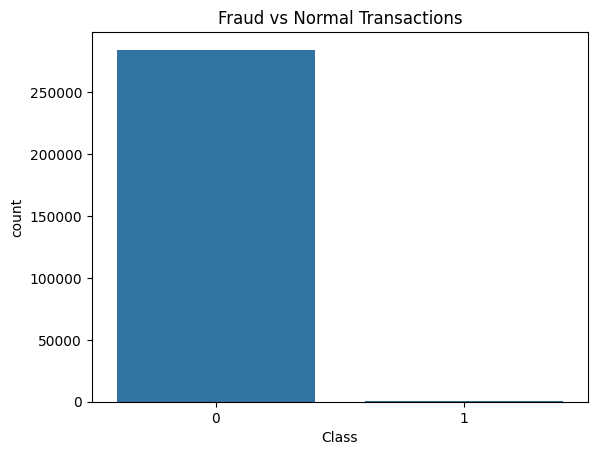

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.savefig(f'{output_folder}/fraud_vs_normal_transactions.png') # Save the plot
plt.show()

### Transaction Amount Distribution

We analyze how transaction amounts are spread across all transactions.

This helps identify outliers and general spending patterns.

The distribution shows that **most transactions have small amounts**, with a long tail indicating a few transactions with very high amounts. This skewness is common in financial data.

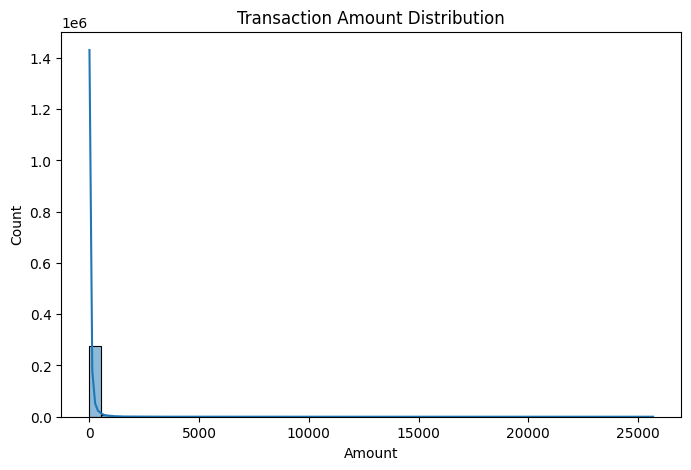

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.savefig(f'{output_folder}/transaction_amount_distribution.png')
plt.show()

### Fraud vs Amount

This comparison helps determine whether fraudulent transactions differ in value compared to normal ones.

The box plot reveals that **fraudulent transactions generally have lower amounts** than normal transactions, though there are some fraudulent transactions with higher values. This difference in distribution can be a useful feature for detection.

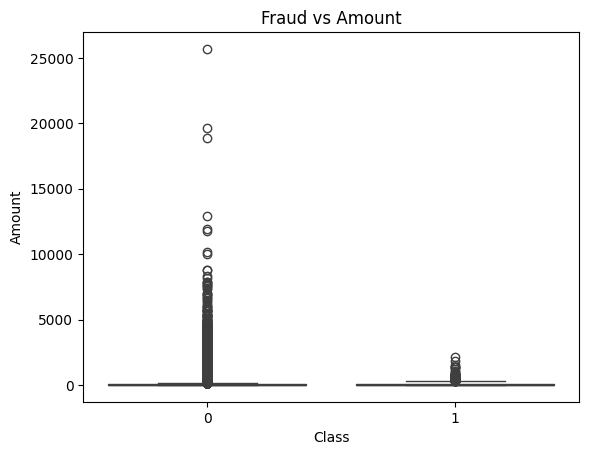

In [54]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Fraud vs Amount")
plt.savefig(f'{output_folder}/fraud_vs_amount_boxplot.png')
plt.show()

### Time Distribution

We analyze when transactions occur over time to detect any temporal patterns.

The histogram for 'Time' reveals two distinct peaks, suggesting that transaction activity might be higher during certain periods (e.g., specific hours of the day or days of the week). This pattern could be useful in understanding transaction behavior, although `Time` was eventually scaled for model input rather than used as a direct temporal feature.

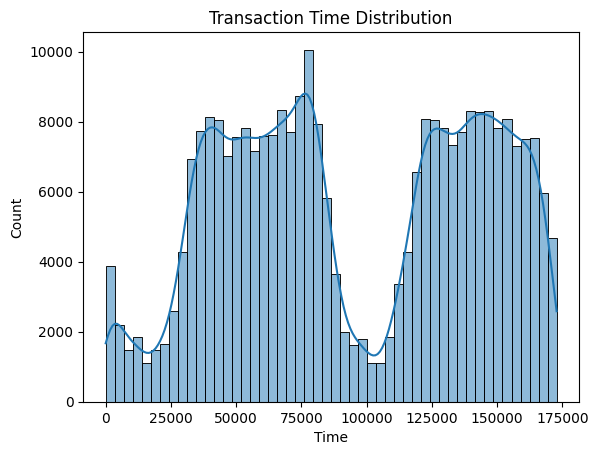

In [55]:
sns.histplot(df['Time'], bins=50, kde=True)
plt.title("Transaction Time Distribution")
plt.savefig(f'{output_folder}/transaction_time_distribution.png')
plt.show()

### Correlation Analysis

This shows relationships between features.

Since the dataset uses PCA, most features are not highly correlated.

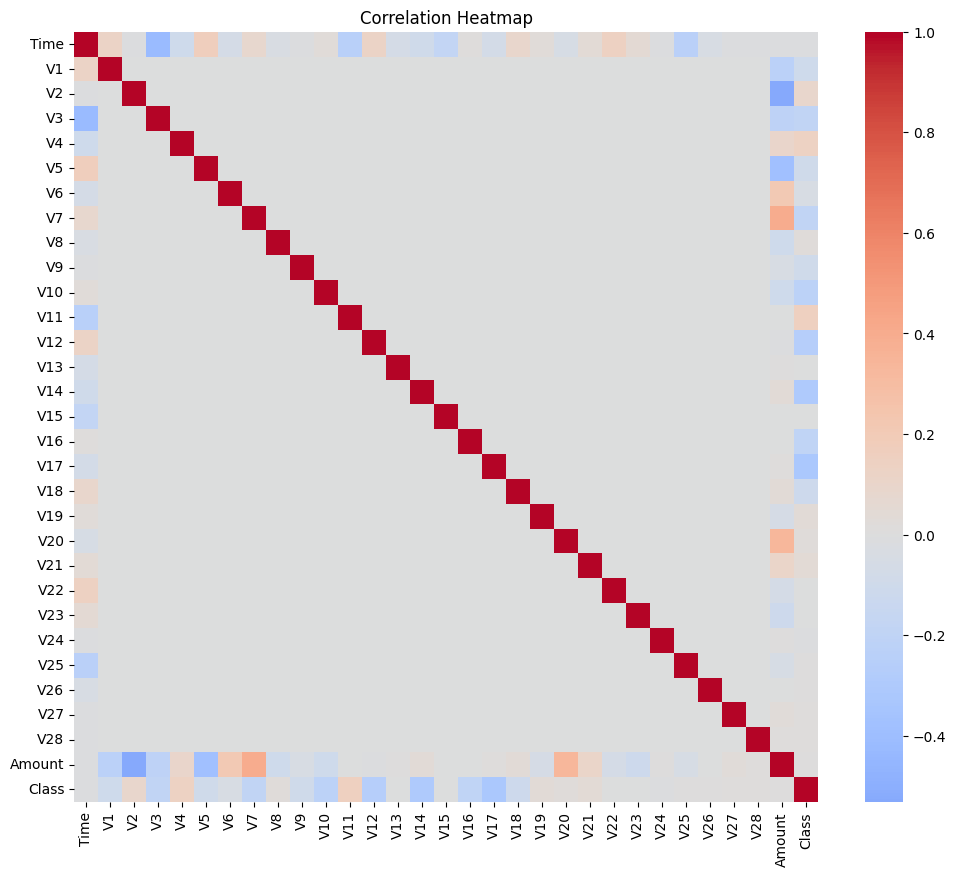

In [56]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.savefig(f'{output_folder}/correlation_heatmap.png')
plt.show()

### PCA Features

The dataset uses anonymized PCA features (V1–V28).

These features do not have direct meaning but capture patterns in the data. Their distributions are generally standardized, making them suitable inputs for neural networks.

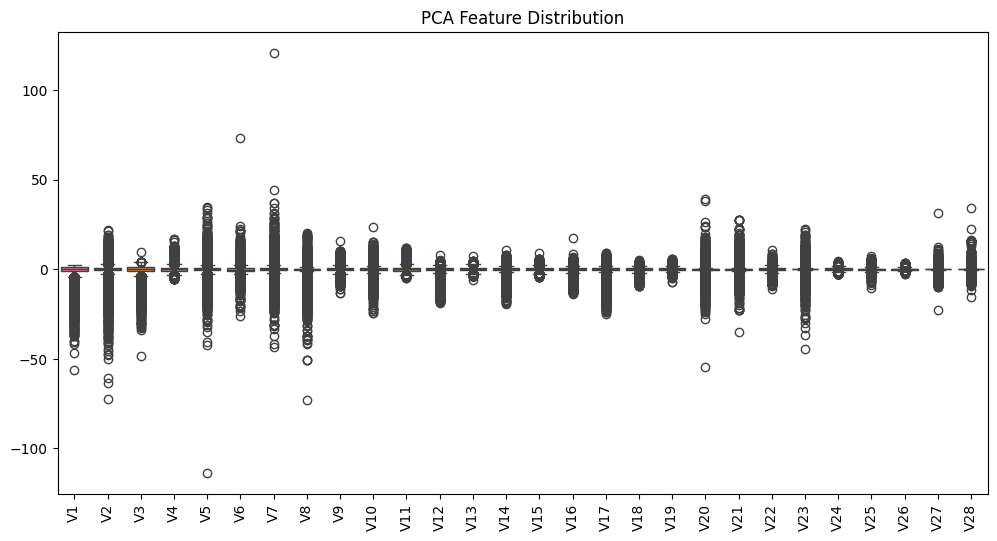

In [57]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.iloc[:, 1:29])
plt.xticks(rotation=90)
plt.title("PCA Feature Distribution")
plt.savefig(f'{output_folder}/pca_feature_distribution.png')
plt.show()

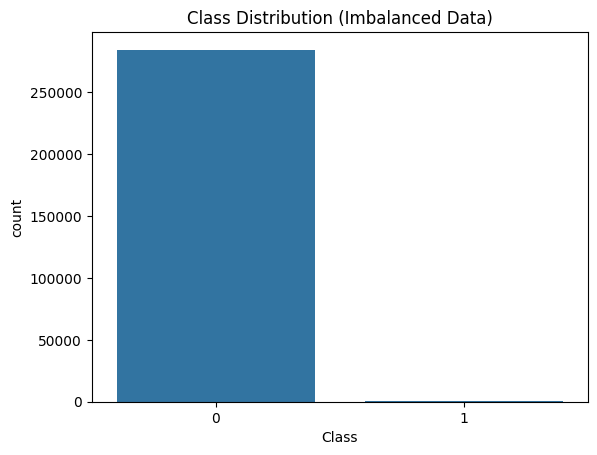

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title("Class Distribution (Imbalanced Data)")
plt.savefig(f'{output_folder}/class_distribution_imbalanced.png')
plt.show()

In [59]:
df['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


In [60]:
# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Convert to numpy (optional but clean)
X = X.values
y = y.values

## Data Splitting

Before training any models, it's crucial to split the data into training and testing sets. This ensures that we evaluate our model on unseen data, providing a more realistic assessment of its performance. Given the highly imbalanced nature of our dataset, we will use stratified sampling to maintain the class distribution in both the training and testing sets.

In [61]:
from sklearn.model_selection import train_test_split

# Perform train-test split
# Using stratify=y to ensure the proportion of classes is maintained in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nClass distribution in y_train:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

print("\nClass distribution in y_test:")
print(pd.Series(y_test).value_counts(normalize=True) * 100)

X_train shape: (227845, 30)
X_test shape: (56962, 30)
y_train shape: (227845,)
y_test shape: (56962,)

Class distribution in y_train:
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Class distribution in y_test:
0    99.827955
1     0.172045
Name: proportion, dtype: float64


## Model Training (Without Scaling)

We train the neural network directly on raw data without scaling.

This allows us to observe:
- Training stability
- Model performance
- Effect of feature magnitude differences

In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(32, activation='relu', input_dim=X.shape[1]),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9474 - loss: 899.1580 - val_accuracy: 0.9979 - val_loss: 0.0380
Epoch 2/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9980 - loss: 0.1507 - val_accuracy: 0.9983 - val_loss: 0.6558
Epoch 3/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9980 - loss: 0.6526 - val_accuracy: 0.9983 - val_loss: 1.7526
Epoch 4/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9972 - loss: 3.4641 - val_accuracy: 0.9983 - val_loss: 0.6102
Epoch 5/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9982 - loss: 0.2455 - val_accuracy: 0.9983 - val_loss: 0.7823
Epoch 6/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9974 - loss: 0.1029 - val_accuracy: 0.9983 - val_loss: 1.9842
Epoch 7/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9967 - loss: 3.2846 - val_accuracy: 0.9983 - val_loss: 2.6622
Epoch 8/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9983 - loss: 0.4950 - val_accuracy: 

## Evaluation (Without Scaling)

We evaluate the model using:
- Accuracy
- Precision
- Recall
- ROC-AUC

This helps us understand how well the model performs without feature normalization.

In [64]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Predictions
y_pred_prob = model.predict(X)
y_pred = (y_pred_prob > 0.5).astype(int)

# Report
print(classification_report(y, y_pred))

8901/8901 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.11      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.55      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807



## Confusion Matrix (Imbalanced Model)

The confusion matrix shows how the model performs on the imbalanced dataset.

Key observations:
- High true negatives (normal transactions correctly identified)
- Low true positives (fraud cases detected)
- Many fraud cases are missed (false negatives)

This indicates that the model struggles to detect fraud due to class imbalance.

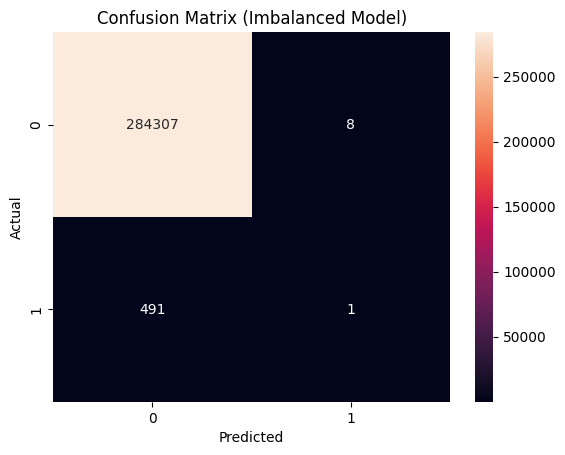

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_imbalanced = confusion_matrix(y, y_pred)

sns.heatmap(cm_imbalanced, annot=True, fmt='d')
plt.title("Confusion Matrix (Imbalanced Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f'{output_folder}/confusion_matrix_imbalanced.png')
plt.show()

## ROC Curve (Imbalanced Model)

The ROC curve evaluates the model’s ability to distinguish between fraud and normal transactions.

Although the ROC-AUC may appear high, it can be misleading in imbalanced datasets.

This is because the model is biased toward the majority class.

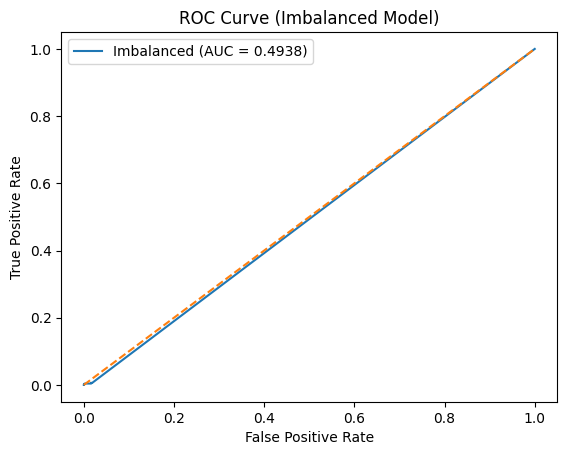

In [66]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_imb, tpr_imb, _ = roc_curve(y, y_pred_prob)
roc_auc_imb = roc_auc_score(y, y_pred_prob)

plt.plot(fpr_imb, tpr_imb, label=f"Imbalanced (AUC = {roc_auc_imb:.4f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Imbalanced Model)")
plt.legend()
plt.savefig(f'{output_folder}/roc_curve_imbalanced.png')
plt.show()

## Handling Class Imbalance for Neural Network

The dataset is highly imbalanced, which affects the model’s ability to detect fraud.

To address this, we balance the dataset using SMOTE.

This allows the neural network to learn patterns from both classes more effectively.

## Feature Scaling (Selective)

The dataset contains:
- PCA features (V1–V28) → already normalized
- Time and Amount → not scaled

We scale only Time and Amount to ensure balanced feature influence.

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale only Time and Amount in TRAINING data using their numerical indices
# 'Time' is at index 0 and 'Amount' is at index 29 in the X_train array
X_train[:, [0, 29]] = scaler.fit_transform(X_train[:, [0, 29]])

# Apply SAME scaling to TEST data using their numerical indices
X_test[:, [0, 29]] = scaler.transform(X_test[:, [0, 29]])

## Applying SMOTE

We apply SMOTE to the training data to balance the classes.

This generates synthetic fraud samples and improves the model’s ability to detect fraud.

In [68]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

## Balanced Data Visualization

After applying SMOTE:
- Fraud and normal classes are now balanced

This allows the model to learn patterns from both classes equally.

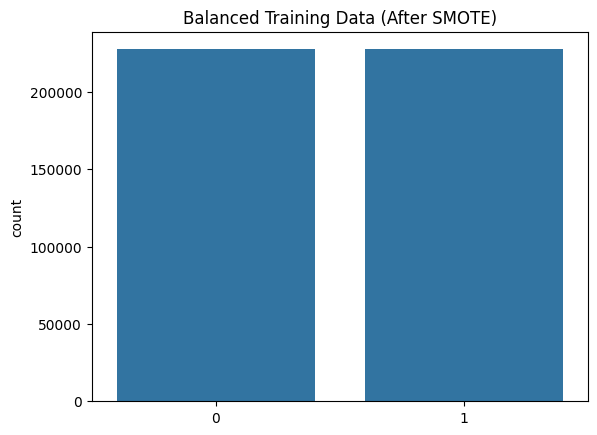

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train_bal)
plt.title("Balanced Training Data (After SMOTE)")
plt.savefig(f'{output_folder}/balanced_training_data_smote.png')
plt.show()

## Neural Network Training (Balanced Data)

We train the neural network on the balanced dataset.

This improves the model’s ability to detect fraud cases.

In [70]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_bal = Sequential([
    Dense(32, activation='relu', input_dim=X_train_bal.shape[1]),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_bal.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_bal = model_bal.fit(
    X_train_bal, y_train_bal,
    epochs=10,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1422/1422 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9664 - loss: 0.0964 - val_accuracy: 0.9872 - val_loss: 0.0393
Epoch 2/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9939 - loss: 0.0202 - val_accuracy: 0.9996 - val_loss: 0.0120
Epoch 3/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9975 - loss: 0.0106 - val_accuracy: 0.9984 - val_loss: 0.0105
Epoch 4/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9986 - loss: 0.0070 - val_accuracy: 0.9997 - val_loss: 0.0074
Epoch 5/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9989 - loss: 0.0052 - val_accuracy: 0.9999 - val_loss: 0.0047
Epoch 6/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9991 - loss: 0.0042 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 7/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9993 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 8/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accura

## Evaluation (Balanced Data)

We evaluate the model using:
- Precision
- Recall
- ROC-AUC

We compare these results with the imbalanced model.

In [71]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_prob_bal = model_bal.predict(X_test)
y_pred_bal = (y_pred_prob_bal > 0.5).astype(int)

print(classification_report(y_test, y_pred_bal))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob_bal))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.63      0.85      0.72        98

    accuracy                           1.00     56962
   macro avg       0.82      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9666752322763659


## Confusion Matrix (Balanced Model)

The confusion matrix shows how the model performs on the balanced dataset.

Key observations:
- High true negatives (normal transactions correctly identified)
- Low true positives (fraud cases detected)
- Many fraud cases are missed (false negatives)

This indicates that the model tries to detect fraud due to class balance.

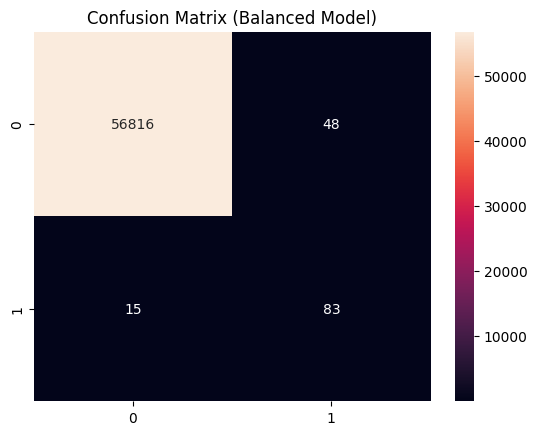

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_bal)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Balanced Model)")
plt.savefig(f'{output_folder}/confusion_matrix_balanced.png')
plt.show()

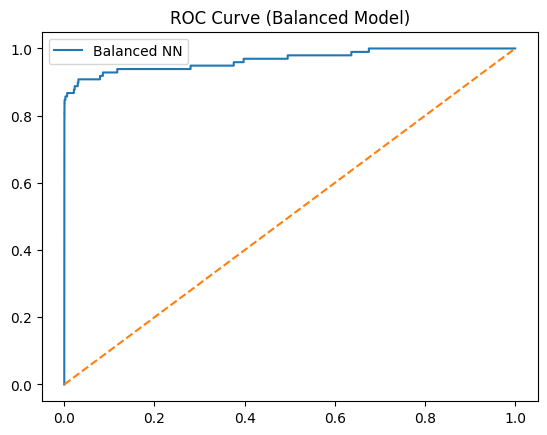

In [73]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_prob_bal)

plt.plot(fpr, tpr, label="Balanced NN")
plt.plot([0,1], [0,1], linestyle='--')
plt.legend()
plt.title("ROC Curve (Balanced Model)")
plt.savefig(f'{output_folder}/roc_curve_balanced.png')
plt.show()

## ROC Curve Comparison

We compare the ROC curves of:
- Imbalanced model
- Balanced model

The balanced model typically shows better performance in distinguishing fraud cases.

This confirms that handling class imbalance improves model effectiveness.

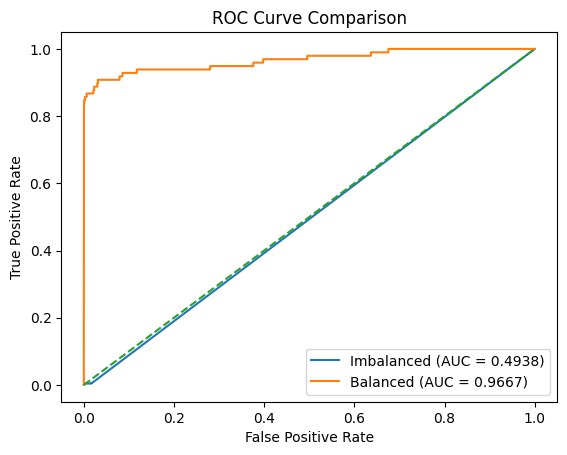

In [74]:
# Balanced already computed earlier
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_pred_prob_bal)
roc_auc_bal = roc_auc_score(y_test, y_pred_prob_bal)

plt.plot(fpr_imb, tpr_imb, label=f"Imbalanced (AUC = {roc_auc_imb:.4f})")
plt.plot(fpr_bal, tpr_bal, label=f"Balanced (AUC = {roc_auc_bal:.4f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig(f'{output_folder}/roc_curve_comparison.png')
plt.show()

In [75]:
import os

output_folder = 'visualizations'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f'Folder \'{output_folder}\' created successfully.')
else:
    print(f'Folder \'{output_folder}\' already exists.')

Folder 'visualizations' already exists.


In [77]:
import shutil
import os

source_folder = 'visualizations'
destination_folder = '/content/drive/MyDrive/visualizations'

# Create the destination folder in Google Drive if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# Copy the contents of the source folder to the destination folder
# use copytree for copying directories, if it exists then remove it first
if os.path.exists(destination_folder):
    shutil.rmtree(destination_folder)
shutil.copytree(source_folder, destination_folder)

print(f"Folder '{source_folder}' successfully copied to '{destination_folder}' in Google Drive.")

Folder 'visualizations' successfully copied to '/content/drive/MyDrive/visualizations' in Google Drive.
